<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/machina_learning/lab%20-%20Decision%20Trees%20and%20Random%20Forests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Trees and Random Forests

**Theory:** [notes_ML/06_decision_trees_cart.ipynb](../notes_ML/06_decision_trees_cart.ipynb) and [notes_ML/07_bagging_random_forest_boosting.ipynb](../notes_ML/07_bagging_random_forest_boosting.ipynb). This lab only uses them.

A decision tree splits the feature space into rectangles and predicts one value per rectangle. A single deep tree fits the training data very well but is unstable (high variance). A random forest averages many randomised trees to cancel out that instability.

### Learning Objectives
- See how a tree splits the data, and how depth controls overfitting
- See why a single tree is unstable
- Reduce variance with bagging and random forests
- Use the out-of-bag (OOB) score and choose the number of trees
- Use random forests for regression and read feature importances

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_text
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split

plt.style.use('seaborn-v0_8-whitegrid')


def visualize_classifier(model, X, y, ax=None, boundaries=False, cmap='rainbow'):
    """Fit `model` on (X, y) and plot the predicted class regions in 2D.
    If boundaries=True (single trees only), also draw the split lines."""
    ax = ax or plt.gca()

    # Plot the training points
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=cmap,
               clim=(y.min(), y.max()), edgecolors='white', linewidths=0.3, zorder=3)
    ax.axis('tight')
    ax.axis('off')
    xlim, ylim = ax.get_xlim(), ax.get_ylim()

    # Fit the model and predict on a grid
    model.fit(X, y)
    xx, yy = np.meshgrid(np.linspace(*xlim, num=200), np.linspace(*ylim, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Colour each region by its predicted class
    n_classes = len(np.unique(y))
    ax.contourf(xx, yy, Z, alpha=0.3, levels=np.arange(n_classes + 1) - 0.5,
                cmap=cmap, clim=(y.min(), y.max()), zorder=1)
    ax.set(xlim=xlim, ylim=ylim)

    # Draw the split lines by walking the fitted tree recursively
    def plot_boundaries(i, xlim, ylim):
        if i < 0:                       # -1 means "no child" (leaf)
            return
        tree = model.tree_
        f, t = tree.feature[i], tree.threshold[i]
        if f == 0:                      # vertical line x1 = t
            ax.plot([t, t], ylim, '-k', lw=1, zorder=2)
            plot_boundaries(tree.children_left[i],  [xlim[0], t], ylim)
            plot_boundaries(tree.children_right[i], [t, xlim[1]], ylim)
        elif f == 1:                    # horizontal line x2 = t
            ax.plot(xlim, [t, t], '-k', lw=1, zorder=2)
            plot_boundaries(tree.children_left[i],  xlim, [ylim[0], t])
            plot_boundaries(tree.children_right[i], xlim, [t, ylim[1]])

    if boundaries:
        plot_boundaries(0, xlim, ylim)

## 1. How a Decision Tree Makes Decisions

A tree asks a sequence of yes/no questions about the features, like a game of "20 questions":

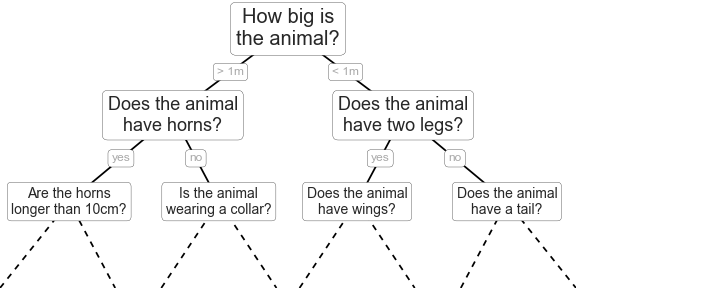

In machine learning each question is of the form $x_j \le \theta$ (one feature, one threshold), so the regions are **axis-aligned rectangles**. A leaf predicts the majority class (classification) or the mean target (regression).

To choose a question, CART tries every feature and threshold and keeps the split that makes the two children most "pure". For classification the default impurity is the **Gini index** of a node, where $p_k$ is the fraction of class $k$ in it:

$$G = 1 - \sum_k p_k^2 \qquad (0 = \text{pure node})$$

In code: 1) for each feature and threshold, split the node in two, 2) compute the size-weighted Gini of the children, 3) keep the split with the lowest value, 4) repeat on each child. Details and a worked example: notes 06, sections 3-6. A from-scratch version is in the *Decision Trees from scratch* lab.

Let's use a 2D dataset with 4 classes:

In [ ]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=4, random_state=0, cluster_std=1.0)

plt.figure(figsize=(6, 5))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='rainbow', edgecolors='white', linewidths=0.4)
plt.colorbar(scatter, label='Class')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Dataset: 4-Class Blob Classification')
plt.tight_layout()
plt.show()

A shallow tree is easy to read. `export_text` prints the questions and the class counts reaching each leaf:

In [ ]:
tree2 = DecisionTreeClassifier(max_depth=2, random_state=0).fit(X, y)
print(export_text(tree2, feature_names=['x1', 'x2'], show_weights=True))

Each extra level splits every impure region again. Watch the boundary as the depth grows (black lines are the splits):

In [ ]:
depths = [1, 2, 3, 5, None]            # None = grow until every leaf is pure
fig, ax = plt.subplots(1, len(depths), figsize=(17, 3.4))

for axi, depth in zip(ax, depths):
    model = DecisionTreeClassifier(max_depth=depth, random_state=0)
    visualize_classifier(model, X, y, ax=axi, boundaries=True)
    axi.set_title(f'max_depth = {depth}  ({model.get_n_leaves()} leaves)', fontsize=10)

fig.suptitle('Decision Tree: Effect of Depth on the Decision Boundary', y=1.03, fontsize=12)
plt.show()

With no depth limit the tree keeps splitting until every leaf is pure, carving tiny regions around single noisy points.

## 2. Depth and Overfitting

Let's measure it: train trees of increasing depth and compare training and test accuracy.

In [ ]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=0)

depth_list = range(1, 16)
train_acc, test_acc = [], []
for d in depth_list:
    clf = DecisionTreeClassifier(max_depth=d, random_state=0).fit(X_tr, y_tr)
    train_acc.append(clf.score(X_tr, y_tr))
    test_acc.append(clf.score(X_te, y_te))

best = depth_list[int(np.argmax(test_acc))]
print(f"Best test accuracy {max(test_acc):.3f} at max_depth = {best}")
print(f"Deepest tree (depth {depth_list[-1]}): train {train_acc[-1]:.3f}, test {test_acc[-1]:.3f}")

plt.figure(figsize=(7, 4))
plt.plot(depth_list, train_acc, 'o-', label='Train')
plt.plot(depth_list, test_acc, 's-', label='Test')
plt.axvline(best, color='gray', ls='--', lw=1, label=f'best depth = {best}')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Tree Depth vs Overfitting')
plt.legend()
plt.tight_layout()
plt.show()

Training accuracy climbs to 1.0, but test accuracy stops improving after a few levels and then drops a little: deep trees fit noise. Limiting `max_depth` (or `min_samples_leaf`, or pruning with `ccp_alpha`) controls this; see notes 06, section 9.

### A single tree is unstable

A deep tree is **low bias, high variance**. Train the same tree on two halves of the data (even and odd samples):

In [ ]:
model = DecisionTreeClassifier(random_state=0)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
visualize_classifier(model, X[::2],  y[::2],  ax=ax[0])
visualize_classifier(model, X[1::2], y[1::2], ax=ax[1])
ax[0].set_title('Tree trained on even-indexed samples', fontsize=11)
ax[1].set_title('Tree trained on odd-indexed samples',  fontsize=11)
fig.suptitle('Same data source, different sample: different boundaries', fontsize=12)
plt.tight_layout()
plt.show()

The two trees agree far from the class borders but disagree in the overlap regions, where a few points decide each split. If we **average many such trees**, those random differences cancel out. That is the idea behind bagging and random forests.

## 3. Bagging and Random Forests

The key fact (notes 07, section 1): averaging $B$ models, each with variance $\sigma^2$ and pairwise correlation $\rho$, gives

$$\text{Var}(\text{average}) = \rho\,\sigma^2 + \frac{1-\rho}{B}\,\sigma^2$$

More trees kill the second term; less correlated trees shrink the first.

- **Bagging** (bootstrap aggregating): train each tree on a **bootstrap sample** (draw $m$ points with replacement), then take a majority vote (or the mean for regression).
- **Random forest**: bagging plus, at **every split**, only a random subset of `max_features` features is considered (default $\sqrt{n}$ for classification). This makes the trees less correlated (smaller $\rho$).

In code: 1) draw a bootstrap sample, 2) grow a deep tree on it (random forest: random features at each split), 3) repeat $B$ times, 4) vote.

Compare a single tree, bagging, and a random forest on the same data:

In [ ]:
models = {
    'Single tree':               DecisionTreeClassifier(random_state=0),
    'Bagging (200 trees)':       BaggingClassifier(DecisionTreeClassifier(), n_estimators=200,
                                                   random_state=0),
    'Random forest (200 trees)': RandomForestClassifier(n_estimators=200, random_state=0),
}

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
for axi, (name, clf) in zip(ax, models.items()):
    visualize_classifier(clf, X_tr, y_tr, ax=axi)
    axi.set_title(f'{name}\ntest acc = {clf.score(X_te, y_te):.3f}', fontsize=11)
plt.tight_layout()
plt.show()

Averaging smooths out the jagged, isolated regions of the single tree, and test accuracy goes up. With only 2 features, random feature selection has little room to act, so bagging and the random forest look alike here; the difference is larger with many features.

### Out-of-bag (OOB) score and number of trees

A bootstrap sample contains about 63% of the distinct training points, so each tree never sees about 37% of them (notes 07, section 2). Predicting each point using only the trees that did not see it gives the **OOB score**: a free validation estimate, no separate validation set needed.

In [ ]:
# Fraction of distinct points in one bootstrap sample
rng = np.random.RandomState(0)
m = 10_000
print(f"Distinct points in a bootstrap sample: {len(np.unique(rng.randint(0, m, m))) / m:.3f}")

Now a harder dataset with 20 features (only 5 informative) and 5% flipped labels. We grow a forest tree by tree and track the test error and the OOB error:

In [ ]:
from sklearn.datasets import make_classification

Xc, yc = make_classification(n_samples=2000, n_features=20, n_informative=5,
                             n_redundant=5, flip_y=0.05, random_state=0)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.5, random_state=0)

tree_err = 1 - DecisionTreeClassifier(random_state=0).fit(Xc_tr, yc_tr).score(Xc_te, yc_te)

# warm_start=True keeps the existing trees and only adds new ones
rf = RandomForestClassifier(warm_start=True, oob_score=True, random_state=0)
n_list = [1, 3, 5, 10, 20, 50, 100, 200, 300]
test_err, oob_err = [], []
for n in n_list:
    rf.set_params(n_estimators=n)
    rf.fit(Xc_tr, yc_tr)
    test_err.append(1 - rf.score(Xc_te, yc_te))
    oob_err.append(1 - rf.oob_score_)

print(f"Single tree test error:           {tree_err:.3f}")
print(f"Random forest ({n_list[-1]} trees) test error: {test_err[-1]:.3f}   OOB error: {oob_err[-1]:.3f}")

plt.figure(figsize=(7, 4))
plt.plot(n_list, test_err, 'o-', label='RF test error')
plt.plot(n_list, oob_err, 's--', label='RF OOB error')
plt.axhline(tree_err, color='gray', ls=':', label='single tree test error')
plt.xscale('log')
plt.xlabel('Number of trees (n_estimators, log scale)')
plt.ylabel('Error')
plt.title('Error vs Number of Trees')
plt.legend()
plt.tight_layout()
plt.show()

- The forest is far better than a single tree.
- The error drops fast and then **levels off**: more trees do not cause overfitting, they only cost compute.
- With very few trees the OOB error is too pessimistic (each point is left out by only a handful of trees). From about 50 trees on it matches the test error, so it can replace a validation set for tuning.

## 4. Random Forest Regression

For regression, each leaf predicts the mean of its training targets, and the forest averages the trees. We use a noisy 1D signal $y = \sin(\pi x) + \sin(0.2x) + \varepsilon$:

In [ ]:
rng = np.random.RandomState(42)
x = 10 * rng.rand(200)

def model(x, sigma=0.3):
    fast_oscillation = np.sin(np.pi * x)
    slow_oscillation = np.sin(0.2 * x)
    noise = sigma * rng.randn(len(x))
    return slow_oscillation + fast_oscillation + noise

y = model(x)

tree_reg = DecisionTreeRegressor(random_state=0).fit(x[:, None], y)
forest   = RandomForestRegressor(n_estimators=100, random_state=42).fit(x[:, None], y)

xfit  = np.linspace(0, 10, 1000)
ytrue = model(xfit, sigma=0)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for axi, (name, reg, c) in zip(ax, [('Single deep tree', tree_reg, 'tab:orange'),
                                    ('Random forest (100 trees)', forest, 'r')]):
    axi.scatter(x, y, s=12, alpha=0.5, color='steelblue', label='Noisy data')
    axi.plot(xfit, reg.predict(xfit[:, None]), color=c, lw=1.5, label=name)
    axi.plot(xfit, ytrue, '--k', lw=1.5, alpha=0.6, label='True signal')
    mse = np.mean((reg.predict(xfit[:, None]) - ytrue) ** 2)
    axi.set_title(f'{name}: MSE vs true signal = {mse:.3f}')
    axi.set_xlabel('x')
    axi.set_ylim(-1.5, 3.2)
    axi.legend(loc='upper left', ncol=3, fontsize=9)
ax[0].set_ylabel('y')
plt.tight_layout()
plt.show()

The single tree is a step function that jumps to follow every noisy point. The forest averages 100 such step functions, which gives a smoother curve closer to the true signal (about half the error), without choosing a polynomial degree or a bandwidth.

## 5. Feature Importance

Two common ways to ask "which features does the forest use?" (notes 07, section 5):

- **MDI** (`feature_importances_`): total impurity decrease from the splits on each feature, averaged over trees. Free to compute, but biased towards features with many distinct values.
- **Permutation importance**: shuffle one feature in the test set and measure how much the score drops. Slower, but measured on held-out data.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.inspection import permutation_importance

iris = load_iris()
X_tr_iris, X_te_iris, y_tr_iris, y_te_iris = train_test_split(
    iris.data, iris.target, test_size=0.3, random_state=42)

rf_iris = RandomForestClassifier(n_estimators=200, random_state=42, oob_score=True)
rf_iris.fit(X_tr_iris, y_tr_iris)

print(f"Test accuracy: {rf_iris.score(X_te_iris, y_te_iris):.3f}")
print(f"OOB accuracy:  {rf_iris.oob_score_:.3f}")

mdi_imp = rf_iris.feature_importances_                        # MDI
perm = permutation_importance(rf_iris, X_te_iris, y_te_iris,  # permutation
                              n_repeats=30, random_state=42)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
ax1.barh(iris.feature_names, mdi_imp, color='steelblue')
ax1.set_xlabel('MDI importance')
ax1.set_title('Mean Decrease in Impurity (MDI)')

ax2.barh(iris.feature_names, perm.importances_mean, xerr=perm.importances_std,
         color='darkorange', capsize=3)
ax2.set_xlabel('Drop in test accuracy when shuffled')
ax2.set_title('Permutation Importance')

fig.suptitle('Feature Importance: Iris Dataset', fontsize=13)
plt.tight_layout()
plt.show()

for name, a, b in zip(iris.feature_names, mdi_imp, perm.importances_mean):
    print(f"{name:20s}  MDI = {a:.3f}   permutation = {b:.3f}")

Both methods agree that the petal measurements carry almost all the information; the sepal features matter little. Note that petal length and width are strongly correlated, so the forest can use either one: importances are shared between correlated features.

## Summary

| | Single decision tree | Random forest |
|---|---|---|
| Model | One tree of axis-aligned splits | Average / vote of many randomised trees |
| Bias / variance | Low bias, **high variance** | Low bias, **lower variance** |
| Key hyperparameters | `max_depth`, `min_samples_leaf` | `n_estimators`, `max_features`, `max_depth` |
| Interpretability | Excellent (readable rules) | Feature importances only |
| Feature scaling | Not needed | Not needed |
| Validation | Needs a validation set | OOB score for free |

Random forests build trees **in parallel** and reduce variance. **Boosting** builds trees **one after another**, each fixing the errors of the previous ones, and mainly reduces bias; see notes 07, section 6 and the *XGBoost and Gradient Boosting* lab.